# Reading Frame Analysis: Comparing Overlapping Gene Stability Across Frames (Multiprocessing Version)

This notebook analyzes how reading frame affects the stability of overlapping genes with **parallel processing**.

**Multiprocessing Features:**
- Automatic CPU core detection
- Parallel trial execution using `multiprocessing.Pool`
- Significant speedup for large scans

**Reading Frames:**
- Frame 0: `overlap % 3 == 0` (in-frame, codons align)
- Frame +1: `overlap % 3 == 1` (shifted by 1 nucleotide)
- Frame +2: `overlap % 3 == 2` (shifted by 2 nucleotides)

**Metrics:**
1. **Final Energy Distance (`Dist`)**: Mean absolute distance from natural mean energy
2. **Minimum Energy Distance (`Min_Dist`)**: Closest approach to natural mean during simulation
3. **Iterations to Convergence (`Iter_Converged`)**: When energy first enters 1 std dev of natural mean

**Analysis:**
- Compare metrics across reading frames
- Statistical tests for frame differences
- Visualizations of frame-specific patterns

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from thesis_plots import *
apply_style()

# --- IMPORTS ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import pandas as pd
import time
import json
import platform
from scipy import stats

# Multiprocessing imports
import multiprocessing
from multiprocessing import Pool, cpu_count
from functools import partial

# Progress bar
from tqdm.auto import tqdm

# Add current directory to path to import overlappingGenes
sys.path.append(os.getcwd())
import overlappingGenes as og


# --- SYSTEM INFO & MULTIPROCESSING SETUP ---
print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)
print(f"Platform:        {platform.system()} {platform.release()}")
print(f"Processor:       {platform.processor()}")
print(f"Python version:  {platform.python_version()}")

# Detect number of CPU cores automatically
N_WORKERS = cpu_count()
print(f"\nCPU Cores Detected: {N_WORKERS}")
print(f"Workers to use:     {N_WORKERS} (all cores)")
print("=" * 60)
print("\nTo use fewer cores, set N_WORKERS manually in the next cell.")
print("Imports complete.")

SYSTEM INFORMATION
Platform:        Darwin 25.2.0
Processor:       arm
Python version:  3.11.15

CPU Cores Detected: 14
Workers to use:     14 (all cores)

To use fewer cores, set N_WORKERS manually in the next cell.
Imports complete.


## Parameters

Configure overlap ranges to include ALL THREE reading frames.


  | Frame | Condition | Meaning |
  |:---:|:---:|:---|
  | **Frame 0** | `overlap % 3 == 0` | **In-frame** — Codons align perfectly. Both genes read the overlap starting at a codon boundary. |
  | **Frame +1** | `overlap % 3 == 1` | **Shifted by 1** — Gene 2 reads the DNA starting 1 nucleotide into Gene 1's codon. |    
  | **Frame +2** | `overlap % 3 == 2` | **Shifted by 2** — Gene 2 reads the DNA starting 2 nucleotides into Gene 1's codon. |   

In [2]:
'''
  Gene 1 codons:  |AAA|BBB|CCC|DDD|
                           ↓ overlap starts here
  Gene 2 Frame 0: |AAA|BBB|CCC|DDD|  ← codons align (overlap = 12, 18, 24...)
  Gene 2 Frame 1:   |AAB|BBC|CCD|    ← shifted 1nt (overlap = 13, 19, 25...)
  Gene 2 Frame 2:    |ABB|BCC|CDD|   ← shifted 2nt (overlap = 14, 20, 26...)
'''

'\n  Gene 1 codons:  |AAA|BBB|CCC|DDD|\n                           ↓ overlap starts here\n  Gene 2 Frame 0: |AAA|BBB|CCC|DDD|  ← codons align (overlap = 12, 18, 24...)\n  Gene 2 Frame 1:   |AAB|BBC|CCD|    ← shifted 1nt (overlap = 13, 19, 25...)\n  Gene 2 Frame 2:    |ABB|BCC|CDD|   ← shifted 2nt (overlap = 14, 20, 26...)\n'

In [2]:
# =============================================================================
# PARAMETERS - All three reading frames
# =============================================================================

# --- MULTIPROCESSING CONFIGURATION ---
# N_WORKERS is auto-detected above, but you can override it here:
# N_WORKERS = 4  # Uncomment to manually set number of workers

def generate_overlaps(start=12, stop=90, reading_frames=[0, 1, 2]):
    """
    Generate overlap values for specified reading frames.
    
    Parameters:
    -----------
    start : int
        Minimum overlap (nucleotides). Must be >= 6.
    stop : int
        Maximum overlap (nucleotides, exclusive).
    reading_frames : list of int
        Which reading frames to include. Options: 0, 1, 2
        
    Returns:
    --------
    list : Sorted list of overlap values
    """
    overlaps = []
    for ov in range(start, stop):
        if ov % 3 in reading_frames:
            overlaps.append(ov)
    return sorted(overlaps)


# === ALL THREE READING FRAMES ===
# Sample overlaps from each frame: 12-90nt range, step of 6 within each frame
# This gives us comparable sample sizes across frames
OVERLAPS_FRAME_0 = list(range(12, 180, 12))   # [12, 18, 24, 30, ...]
OVERLAPS_FRAME_1 = list(range(13, 180, 12))   # [13, 19, 25, 31, ...]
OVERLAPS_FRAME_2 = list(range(14, 180, 12))   # [14, 20, 26, 32, ...]
print(f"Frame 0 overlaps: {OVERLAPS_FRAME_0} ({len(OVERLAPS_FRAME_0)} values)")
print(f"Frame 1 overlaps: {OVERLAPS_FRAME_1} ({len(OVERLAPS_FRAME_1)} values)")
print(f"Frame 2 overlaps: {OVERLAPS_FRAME_2} ({len(OVERLAPS_FRAME_2)} values)")
OVERLAPS = sorted(OVERLAPS_FRAME_0 + OVERLAPS_FRAME_1 + OVERLAPS_FRAME_2)

# --- SIMULATION PARAMETERS ---
ITERATIONS = 250_000      # MC iterations per trial
N_TRIALS = 200             # Number of trials per overlap value
WHENTOSAVE = 0.01         # Save history every 1% of iterations

# --- NORMALIZATION ---
Z_SCORE = True           # If True, normalize distances using z-scores

# Dynamic plot labels based on Z_SCORE
DIST_LABEL = "Z-Score Distance" if Z_SCORE else "Distance from Natural"

# --- PRINT CONFIGURATION ---
print("=" * 60)
print("READING FRAME ANALYSIS CONFIGURATION (MULTIPROCESSING ENABLED)")
print("=" * 60)
print(f"CPU Workers: {N_WORKERS}")
print(f"Total overlaps to scan: {len(OVERLAPS)} values")
print(f"  Frame 0 (in-frame):  {len(OVERLAPS_FRAME_0)} values - {OVERLAPS_FRAME_0[:5]}...")
print(f"  Frame +1:            {len(OVERLAPS_FRAME_1)} values - {OVERLAPS_FRAME_1[:5]}...")
print(f"  Frame +2:            {len(OVERLAPS_FRAME_2)} values - {OVERLAPS_FRAME_2[:5]}...")
print(f"\nSimulation: {ITERATIONS:,} iterations x {N_TRIALS} trials per overlap")
print(f"Z-Score normalization: {Z_SCORE}")
print("=" * 60)

Frame 0 overlaps: [12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 132, 144, 156, 168] (14 values)
Frame 1 overlaps: [13, 25, 37, 49, 61, 73, 85, 97, 109, 121, 133, 145, 157, 169] (14 values)
Frame 2 overlaps: [14, 26, 38, 50, 62, 74, 86, 98, 110, 122, 134, 146, 158, 170] (14 values)
READING FRAME ANALYSIS CONFIGURATION (MULTIPROCESSING ENABLED)
CPU Workers: 14
Total overlaps to scan: 42 values
  Frame 0 (in-frame):  14 values - [12, 24, 36, 48, 60]...
  Frame +1:            14 values - [13, 25, 37, 49, 61]...
  Frame +2:            14 values - [14, 26, 38, 50, 62]...

Simulation: 250,000 iterations x 200 trials per overlap
Z-Score normalization: True


In [3]:
# --- DATA LOADING ---

BASE_DIR = "bmDCA"
try:
    ALL_PF_DIRS = sorted([d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith("PF")])
    print(f"Found {len(ALL_PF_DIRS)} Protein Families: {ALL_PF_DIRS}")
except FileNotFoundError:
    print(f"Error: Base directory '{BASE_DIR}' not found.")
    ALL_PF_DIRS = []

# Cache for parameters to avoid reloading
PARAMS_CACHE = {}
NATURAL_STATS_CACHE = {}

def get_params_and_stats(pf_name):
    if pf_name in PARAMS_CACHE:
        return PARAMS_CACHE[pf_name], NATURAL_STATS_CACHE[pf_name]
    
    # Load DCA Params
    param_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_params.dat")
    J, h = og.extract_params(param_file)
    PARAMS_CACHE[pf_name] = [J, h]
    
    # Load Natural Stats
    nat_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_naturalenergies.txt")
    energies = og.load_natural_energies(nat_file)
    NATURAL_STATS_CACHE[pf_name] = (np.mean(energies), np.std(energies))
    
    return [J, h], (np.mean(energies), np.std(energies))

Found 12 Protein Families: ['PF00004', 'PF00041', 'PF00072', 'PF00076', 'PF00096', 'PF00153', 'PF00271', 'PF00397', 'PF00512', 'PF00595', 'PF02518', 'PF07679']


In [5]:
# --- LOAD OPTIMAL TEMPERATURES ---

OPTIMAL_TEMPS_FILE = "optimal_temperatures.json"
OPTIMAL_TEMPS = {}

if os.path.exists(OPTIMAL_TEMPS_FILE):
    print(f"Loading optimal temperatures from {OPTIMAL_TEMPS_FILE}...")
    with open(OPTIMAL_TEMPS_FILE, 'r') as f:
        OPTIMAL_TEMPS = json.load(f)
    print(f"Loaded temperatures for {len(OPTIMAL_TEMPS)} protein families.")
else:
    print("Warning: optimal_temperatures.json not found. Using default T=1.0 for all.")

Loading optimal temperatures from optimal_temperatures.json...
Loaded temperatures for 12 protein families.


In [4]:
# --- IMPORT WORKER FUNCTION FOR MULTIPROCESSING ---
# Worker function MUST be in a separate .py file for Windows compatibility.
# Windows multiprocessing uses 'spawn' which cannot pickle functions defined in notebook cells.

from multiprocessing_worker import process_single_pair

print("Worker function imported from multiprocessing_worker.py")

Worker function imported from multiprocessing_worker.py


In [7]:
# --- 2. OPTIMIZED PAIR-LEVEL PARALLEL SCAN ---

def run_pairwise_scan_parallel(pf_list, optimal_temps, overlaps=None, z_score=False, n_workers=None):
    """
    Run pairwise overlap scan for all protein family combinations.
    Parallelizes at the PAIR level with maximum optimizations.
    """
    if overlaps is None:
        overlaps = list(OVERLAPS)
    else:
        overlaps = list(overlaps)
    
    if n_workers is None:
        n_workers = N_WORKERS
    
    # Generate Pairs
    pairs = []
    for i in range(len(pf_list)):
        for j in range(i + 1, len(pf_list)):
            pairs.append((pf_list[i], pf_list[j]))
            
    total_pairs = len(pairs)
    total_overlaps = len(overlaps)
    total_simulations = total_pairs * total_overlaps * N_TRIALS
    
    # Print scan configuration
    print("\n" + "=" * 60)
    print("STARTING OPTIMIZED PAIR-LEVEL PARALLEL SCAN")
    print("=" * 60)
    print(f"Protein families:     {len(pf_list)}")
    print(f"Unique pairs:         {total_pairs}")
    print(f"Overlaps per pair:    {total_overlaps} ({min(overlaps)}-{max(overlaps)} nt)")
    print(f"Reading frames:       {sorted(set(ov % 3 for ov in overlaps))}")
    print(f"Trials per overlap:   {N_TRIALS}")
    print(f"Iterations per trial: {ITERATIONS:,}")
    print(f"Total simulations:    {total_simulations:,}")
    print(f"\nParallel workers:     {n_workers}")
    print(f"Parallelization:      PAIR-LEVEL (optimized)")
    print(f"Z-Score norm:         {z_score}")
    print("=" * 60)
    
    # Prepare all pair arguments
    print("\nPreparing pair data...")
    pair_args_list = []
    
    for pf1, pf2 in tqdm(pairs, desc="Loading parameters", unit="pair"):
        params1, (nat_mean1, nat_std1) = get_params_and_stats(pf1)
        params2, (nat_mean2, nat_std2) = get_params_and_stats(pf2)
        
        t1 = optimal_temps.get(pf1, 1.0)
        t2 = optimal_temps.get(pf2, 1.0)
        
        len1 = len(params1[1]) // 21
        len2 = len(params2[1]) // 21
        
        max_overlap = min(len1, len2) * 3 - 6
        valid_overlaps = [ov for ov in overlaps if ov <= max_overlap]
        
        pair_args_list.append((
            pf1, pf2, params1, params2, nat_mean1, nat_mean2, nat_std1, nat_std2,
            t1, t2, valid_overlaps, len1, len2, N_TRIALS, ITERATIONS, WHENTOSAVE, z_score
        ))
    
    print(f"\nStarting parallel processing of {total_pairs} pairs across {n_workers} workers...")
    print("(First few pairs may be slower due to Numba JIT compilation)\n")
    start_time_all = time.time()
    
    # Run with optimizations
    summary_data = []
    completed = 0
    
    with Pool(processes=n_workers, maxtasksperchild=20) as pool:
        results_iter = pool.imap_unordered(process_single_pair, pair_args_list)
        
        pbar = tqdm(total=total_pairs, desc="Processing pairs", unit="pair")
        
        for pair_results in results_iter:
            summary_data.extend(pair_results)
            completed += 1
            pbar.update(1)
            
            # Show intermediate stats every 5 pairs
            if completed % 5 == 0:
                elapsed = time.time() - start_time_all
                rate = completed / elapsed * 60  # pairs per minute
                eta = (total_pairs - completed) / (completed / elapsed) if completed > 0 else 0
                pbar.set_postfix({
                    'rate': f'{rate:.1f}/min',
                    'ETA': f'{eta/60:.1f}min'
                })
        
        pbar.close()
    
    total_dur = time.time() - start_time_all
    
    # Print completion summary
    print("\n" + "=" * 60)
    print("SCAN COMPLETE")
    print("=" * 60)
    print(f"Total time:           {total_dur/60:.1f} minutes ({total_dur:.0f} seconds)")
    print(f"Pairs processed:      {total_pairs}")
    print(f"Results collected:    {len(summary_data)} rows")
    print(f"Avg time/pair:        {total_dur/total_pairs:.1f} seconds")
    print(f"Avg time/simulation:  {total_dur/total_simulations*1000:.1f} ms")
    print(f"Throughput:           {total_simulations/total_dur:.0f} simulations/sec")
    print("=" * 60)
    
    return pd.DataFrame(summary_data)

In [ ]:
# --- RUN THE SCAN ---

RESULTS_FILE = "reading_frame_results.csv"

if __name__ == '__main__':
    # Windows requires this guard for multiprocessing
    if 'ALL_PF_DIRS' in dir() and ALL_PF_DIRS:
        results_df = run_pairwise_scan_parallel(ALL_PF_DIRS, OPTIMAL_TEMPS, z_score=Z_SCORE)
        results_df.to_csv(RESULTS_FILE, index=False)
        print(f"Results saved to {RESULTS_FILE}")
    else:
        print("No protein families found to scan. Check BASE_DIR.")


STARTING OPTIMIZED PAIR-LEVEL PARALLEL SCAN
Protein families:     12
Unique pairs:         66
Overlaps per pair:    42 (12-170 nt)
Reading frames:       [0, 1, 2]
Trials per overlap:   200
Iterations per trial: 250,000
Total simulations:    554,400

Parallel workers:     16
Parallelization:      PAIR-LEVEL (optimized)
Z-Score norm:         True

Preparing pair data...


Loading parameters: 100%|██████████| 66/66 [00:08<00:00,  7.74pair/s]



Starting parallel processing of 66 pairs across 16 workers...
(First few pairs may be slower due to Numba JIT compilation)



Processing pairs:   0%|          | 0/66 [00:00<?, ?pair/s]

---
## Load Results (if already computed)

Run this cell to load previously computed results.

In [6]:
# --- LOAD EXISTING RESULTS ---

RESULTS_FILE = "reading_frame_results.csv"

if os.path.exists(RESULTS_FILE):
    results_df = pd.read_csv(RESULTS_FILE)
    print(f"Loaded {len(results_df)} rows from {RESULTS_FILE}")
    print(f"\nReading frames present: {sorted(results_df['Reading_Frame'].unique())}")
    print(f"Overlaps per frame:")
    for frame in sorted(results_df['Reading_Frame'].unique()):
        n_overlaps = results_df[results_df['Reading_Frame'] == frame]['Overlap'].nunique()
        print(f"  Frame {frame}: {n_overlaps} unique overlap values")
else:
    print(f"Results file '{RESULTS_FILE}' not found. Run the scan first.")

Loaded 2235 rows from reading_frame_results.csv

Reading frames present: [np.int64(0), np.int64(1), np.int64(2)]
Overlaps per frame:
  Frame 0: 14 unique overlap values
  Frame 1: 14 unique overlap values
  Frame 2: 14 unique overlap values


---
## Analysis: Reading Frame Comparison

Compare stability metrics across the three reading frames.

In [9]:
# --- COMPUTE COMBINED METRICS ---
# Average Dist_1 and Dist_2 for a single "stability" measure per row

if 'results_df' in dir():
    results_df['Avg_Dist'] = (results_df['Dist_1'] + results_df['Dist_2']) / 2
    results_df['Avg_Min_Dist'] = (results_df['Min_Dist_1'] + results_df['Min_Dist_2']) / 2
    results_df['Avg_Iter_Conv'] = (results_df['Iter_Converged_1'] + results_df['Iter_Converged_2']) / 2
    
    print("Added combined metrics: Avg_Dist, Avg_Min_Dist, Avg_Iter_Conv")
    results_df.head()

Added combined metrics: Avg_Dist, Avg_Min_Dist, Avg_Iter_Conv


In [10]:
# --- SUMMARY STATISTICS BY READING FRAME ---

if 'results_df' in dir():
    frame_summary = results_df.groupby('Reading_Frame').agg({
        'Avg_Dist': ['mean', 'std', 'median'],
        'Avg_Min_Dist': ['mean', 'std', 'median'],
        'Avg_Iter_Conv': ['mean', 'std', 'median']
    }).round(2)
    
    print("=" * 70)
    print("SUMMARY STATISTICS BY READING FRAME")
    print("=" * 70)
    print(frame_summary)
    print("\nLower Dist = Better (closer to natural energy)")
    print("Lower Iter_Conv = Better (faster convergence)")

SUMMARY STATISTICS BY READING FRAME
              Avg_Dist              Avg_Min_Dist              Avg_Iter_Conv  \
                  mean   std median         mean   std median          mean   
Reading_Frame                                                                 
0                 0.87  0.34   0.80         0.11  0.17   0.04      29601.66   
1                 1.01  0.43   0.93         0.20  0.24   0.10      41999.97   
2                 0.70  0.24   0.64         0.06  0.08   0.02      19957.13   

                                   
                    std    median  
Reading_Frame                      
0              26508.50  19768.75  
1              37392.81  25862.50  
2              12324.59  16343.75  

Lower Dist = Better (closer to natural energy)
Lower Iter_Conv = Better (faster convergence)


In [11]:
# --- STATISTICAL TESTS: KRUSKAL-WALLIS (non-parametric ANOVA) ---
# Tests whether reading frames have significantly different distributions

if 'results_df' in dir():
    print("=" * 70)
    print("KRUSKAL-WALLIS TEST: Are reading frames significantly different?")
    print("=" * 70)
    
    for metric in ['Avg_Dist', 'Avg_Min_Dist', 'Avg_Iter_Conv']:
        groups = [results_df[results_df['Reading_Frame'] == f][metric].values 
                  for f in [0, 1, 2]]
        
        stat, p_value = stats.kruskal(*groups)
        
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        print(f"\n{metric}:")
        print(f"  H-statistic: {stat:.2f}")
        print(f"  p-value: {p_value:.2e} {sig}")
    
    print("\n*** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

KRUSKAL-WALLIS TEST: Are reading frames significantly different?

Avg_Dist:
  H-statistic: 258.89
  p-value: 6.05e-57 ***

Avg_Min_Dist:
  H-statistic: 215.27
  p-value: 1.80e-47 ***

Avg_Iter_Conv:
  H-statistic: 220.98
  p-value: 1.04e-48 ***

*** p<0.001, ** p<0.01, * p<0.05, ns = not significant


In [ ]:
# --- PAIRWISE MANN-WHITNEY U TESTS ---
# If Kruskal-Wallis is significant, test which pairs differ

if 'results_df' in dir():
    print("=" * 70)
    print("PAIRWISE MANN-WHITNEY U TESTS (with Bonferroni correction)")
    print("=" * 70)
    
    frame_pairs = [(0, 1), (0, 2), (1, 2)]
    alpha = 0.05
    bonferroni_alpha = alpha / 3  # 3 comparisons
    
    for metric in ['Avg_Dist', 'Avg_Min_Dist', 'Avg_Iter_Conv']:
        print(f"\n{metric}:")
        for f1, f2 in frame_pairs:
            g1 = results_df[results_df['Reading_Frame'] == f1][metric].values
            g2 = results_df[results_df['Reading_Frame'] == f2][metric].values
            
            stat, p_value = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            
            sig = "*" if p_value < bonferroni_alpha else "ns"
            direction = "<" if np.median(g1) < np.median(g2) else ">" if np.median(g1) > np.median(g2) else "="
            print(f"  Frame {f1} vs Frame {f2}: p={p_value:.2e} {sig} (median: {np.median(g1):.1f} {direction} {np.median(g2):.1f})")
    
    print(f"\nBonferroni-corrected alpha = {bonferroni_alpha:.4f}")

PAIRWISE MANN-WHITNEY U TESTS (with Bonferroni correction)

Avg_Dist:
  Frame 0 vs Frame 1: p=1.05e-09 * (median: 0.8 < 0.9)
  Frame 0 vs Frame 2: p=3.29e-27 * (median: 0.8 > 0.6)
  Frame 1 vs Frame 2: p=4.58e-53 * (median: 0.9 > 0.6)

Avg_Min_Dist:
  Frame 0 vs Frame 1: p=1.74e-13 * (median: 0.0 < 0.1)
  Frame 0 vs Frame 2: p=1.45e-15 * (median: 0.0 > 0.0)
  Frame 1 vs Frame 2: p=1.53e-46 * (median: 0.1 > 0.0)

Avg_Iter_Conv:
  Frame 0 vs Frame 1: p=2.02e-13 * (median: 19768.8 < 25862.5)
  Frame 0 vs Frame 2: p=2.34e-15 * (median: 19768.8 > 16343.8)
  Frame 1 vs Frame 2: p=1.25e-48 * (median: 25862.5 > 16343.8)

Bonferroni-corrected alpha = 0.0167


: 

: 

: 

---
## Visualizations

/var/folders/zv/lpxbcrz505qgxbwn5jmnzz3w0000gn/T/ipykernel_1244/684258037.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='Frame_Label', y='Avg_Dist', ax=axes[0], palette='Set2')
/var/folders/zv/lpxbcrz505qgxbwn5jmnzz3w0000gn/T/ipykernel_1244/684258037.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='Frame_Label', y='Avg_Min_Dist', ax=axes[1], palette='Set2')
/var/folders/zv/lpxbcrz505qgxbwn5jmnzz3w0000gn/T/ipykernel_1244/684258037.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=resul

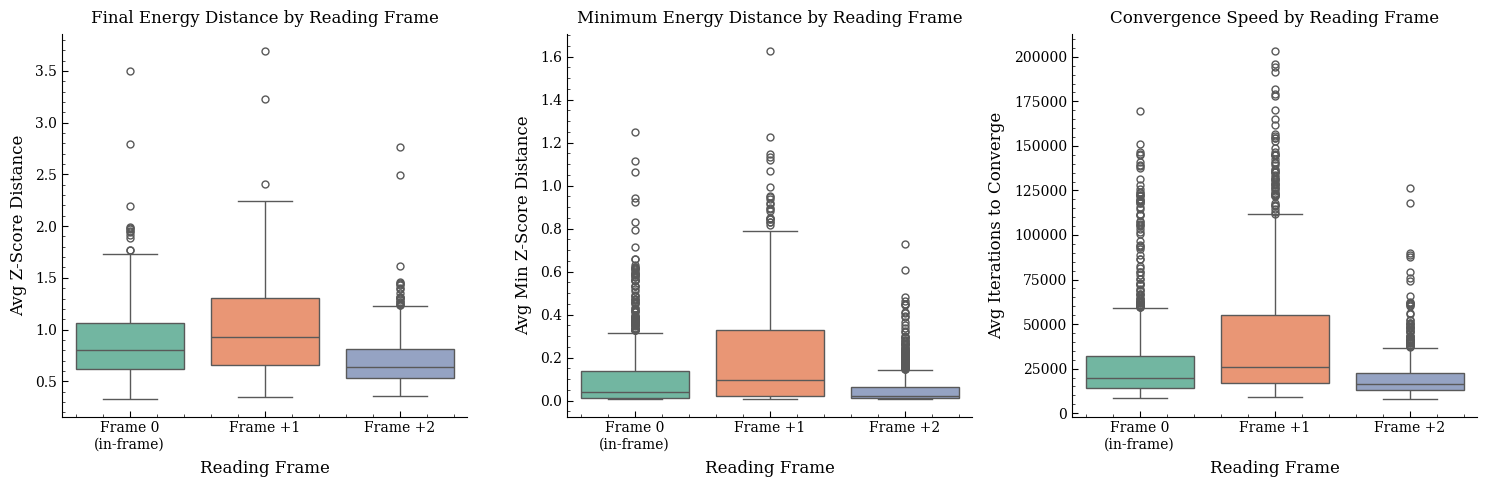

Saved: reading_frame_boxplots.png


In [12]:
# --- BOXPLOT: METRICS BY READING FRAME ---

if 'results_df' in dir():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    frame_labels = {0: 'Frame 0\n(in-frame)', 1: 'Frame +1', 2: 'Frame +2'}
    results_df['Frame_Label'] = results_df['Reading_Frame'].map(frame_labels)
    
    # Dynamic labels based on Z_SCORE
    dist_ylabel = f'Avg {DIST_LABEL}' if Z_SCORE else 'Avg Distance from Natural Mean'
    min_dist_ylabel = f'Avg Min {DIST_LABEL}' if Z_SCORE else 'Avg Min Distance from Natural Mean'
    
    # Plot 1: Average Distance
    sns.boxplot(data=results_df, x='Frame_Label', y='Avg_Dist', ax=axes[0], palette='Set2')
    axes[0].set_title('Final Energy Distance by Reading Frame')
    axes[0].set_xlabel('Reading Frame')
    axes[0].set_ylabel(dist_ylabel)
    
    # Plot 2: Minimum Distance
    sns.boxplot(data=results_df, x='Frame_Label', y='Avg_Min_Dist', ax=axes[1], palette='Set2')
    axes[1].set_title('Minimum Energy Distance by Reading Frame')
    axes[1].set_xlabel('Reading Frame')
    axes[1].set_ylabel(min_dist_ylabel)
    
    # Plot 3: Convergence Iterations
    sns.boxplot(data=results_df, x='Frame_Label', y='Avg_Iter_Conv', ax=axes[2], palette='Set2')
    axes[2].set_title('Convergence Speed by Reading Frame')
    axes[2].set_xlabel('Reading Frame')
    axes[2].set_ylabel('Avg Iterations to Converge')
    
    plt.tight_layout()
    plt.savefig('reading_frame_boxplots.png')
    plt.show()
    print("Saved: reading_frame_boxplots.png")

/var/folders/zv/lpxbcrz505qgxbwn5jmnzz3w0000gn/T/ipykernel_12751/372821901.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=results_df, x='Frame_Label', y='Avg_Dist', ax=axes[0], palette='Set2', inner='quartile')
/var/folders/zv/lpxbcrz505qgxbwn5jmnzz3w0000gn/T/ipykernel_12751/372821901.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=results_df, x='Frame_Label', y='Avg_Min_Dist', ax=axes[1], palette='Set2', inner='quartile')
/var/folders/zv/lpxbcrz505qgxbwn5jmnzz3w0000gn/T/ipykernel_12751/372821901.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` f

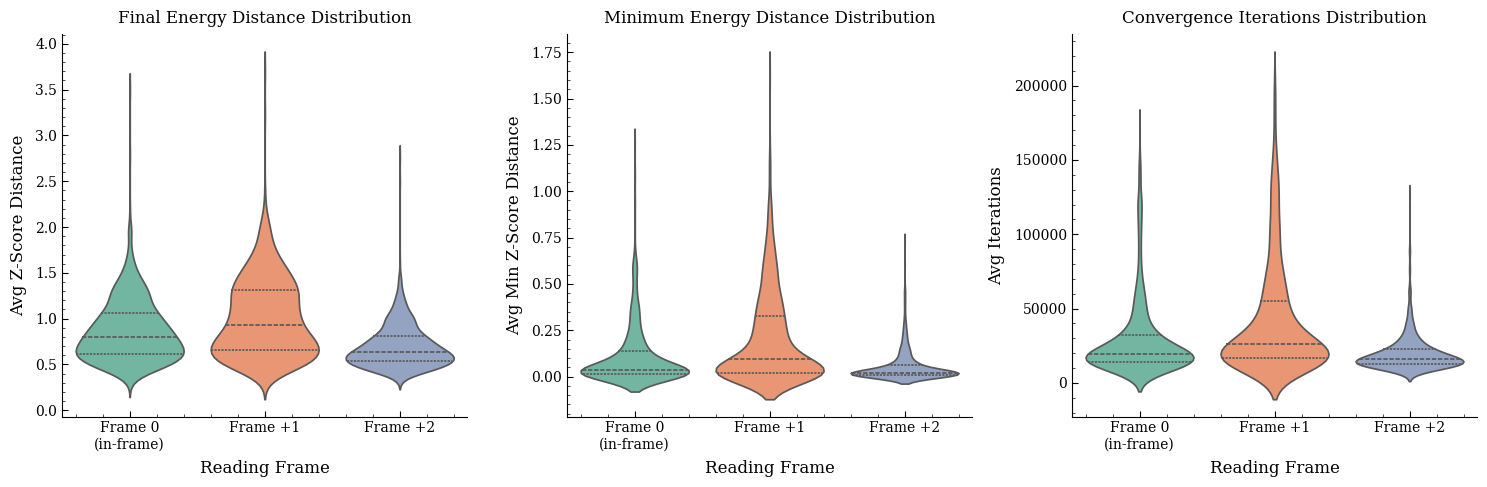

Saved: reading_frame_violins.png


: 

: 

: 

In [ ]:
# --- VIOLIN PLOT: DISTRIBUTION COMPARISON ---

if 'results_df' in dir():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Dynamic labels based on Z_SCORE
    dist_ylabel = f'Avg {DIST_LABEL}' if Z_SCORE else 'Avg Distance'
    min_dist_ylabel = f'Avg Min {DIST_LABEL}' if Z_SCORE else 'Avg Min Distance'
    
    sns.violinplot(data=results_df, x='Frame_Label', y='Avg_Dist', ax=axes[0], palette='Set2', inner='quartile')
    axes[0].set_title('Final Energy Distance Distribution')
    axes[0].set_xlabel('Reading Frame')
    axes[0].set_ylabel(dist_ylabel)
    
    sns.violinplot(data=results_df, x='Frame_Label', y='Avg_Min_Dist', ax=axes[1], palette='Set2', inner='quartile')
    axes[1].set_title('Minimum Energy Distance Distribution')
    axes[1].set_xlabel('Reading Frame')
    axes[1].set_ylabel(min_dist_ylabel)
    
    sns.violinplot(data=results_df, x='Frame_Label', y='Avg_Iter_Conv', ax=axes[2], palette='Set2', inner='quartile')
    axes[2].set_title('Convergence Iterations Distribution')
    axes[2].set_xlabel('Reading Frame')
    axes[2].set_ylabel('Avg Iterations')
    
    plt.tight_layout()
    plt.savefig('reading_frame_violins.png')
    plt.show()
    print("Saved: reading_frame_violins.png")

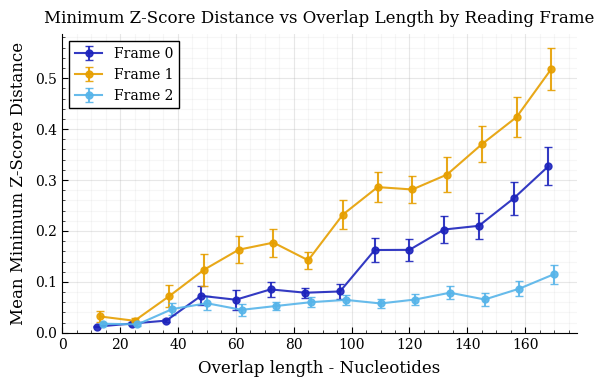

Saved: reading_frame_vs_overlap.png


In [13]:
# --- LINE PLOT: MINIMUM ENERGY DISTANCE VS OVERLAP LENGTH BY FRAME ---

if 'results_df' in dir():
    # Aggregate by overlap and frame
    overlap_frame_agg = results_df.groupby(['Overlap', 'Reading_Frame']).agg({
        'Avg_Min_Dist': ['mean', 'std']
    }).reset_index()
    overlap_frame_agg.columns = ['Overlap', 'Reading_Frame', 'Mean_Min_Dist', 'Std_Min_Dist']

    # Count pairs per overlap/frame for SEM
    counts = results_df.groupby(['Overlap', 'Reading_Frame']).size().reset_index(name='n')
    overlap_frame_agg = overlap_frame_agg.merge(counts, on=['Overlap', 'Reading_Frame'])
    overlap_frame_agg['SEM'] = overlap_frame_agg['Std_Min_Dist'] / np.sqrt(overlap_frame_agg['n'])

    # Thesis-quality styling
    
    frame_colors = FRAME_COLORS
    frame_markers = {0: 'o', 1: 's', 2: '^'}
    frame_names = {0: 'Frame 0', 1: 'Frame 1', 2: 'Frame 2'}

    fig, ax = plt.subplots(figsize=(6, 4))

    for frame in [0, 1, 2]:
        fd = overlap_frame_agg[overlap_frame_agg['Reading_Frame'] == frame].sort_values('Overlap')

        ax.errorbar(fd['Overlap'], fd['Mean_Min_Dist'], yerr=fd['SEM'],
                    label=frame_names[frame], marker='o', linestyle='-',capsize=3, capthick=1,
                    markersize=5, linewidth=1.5, alpha=0.9)

    ax.set_xlabel('Overlap length - Nucleotides')
    ax.set_ylabel('Mean Minimum Z-Score Distance' if Z_SCORE else 'Mean minimum energy distance')
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_title('Minimum Z-Score Distance vs Overlap Length by Reading Frame')
    ax.grid(which='major',alpha=0.3)
    ax.grid(which='minor',alpha=0.1)
    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('reading_frame_vs_overlap.png')
    plt.show()
    print("Saved: reading_frame_vs_overlap.png")

fiugre iut which pair

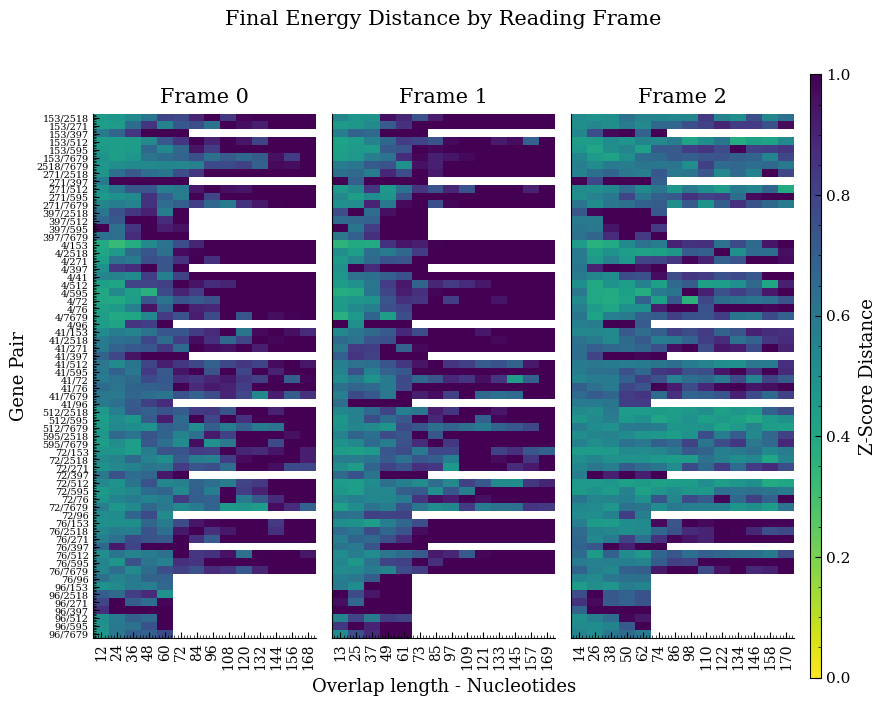

Saved: heatmap_dist_by_frame.png


In [14]:
# --- HEATMAPS: SEPARATE BY READING FRAME ---

def plot_heatmap_by_frame(df, metric, title, vmax=1):
    """Plot heatmaps for each reading frame side by side, print-optimized."""
    import matplotlib.gridspec as gridspec
    
    frame_names = {0: 'Frame 0', 1: 'Frame 1', 2: 'Frame 2'}
    
    # Dynamic colorbar label based on Z_SCORE
    if 'Dist' in metric:
        cbar_label = DIST_LABEL if Z_SCORE else metric
    else:
        cbar_label = metric
    
    # Short pair labels: PF00271 → 271, PF01029 → 1029
    def short_pf(name):
        return name.replace('PF', '').lstrip('0') or '0'
    
    # 3 heatmap columns + 1 narrow colorbar column
    fig, axes = plt.subplots(1, 4, figsize=(9, 7),
                             gridspec_kw={'width_ratios': [1, 1, 1, 0.05]})
    
    for i, frame in enumerate([0, 1, 2]):
        frame_df = df[df['Reading_Frame'] == frame].copy()
        frame_df['Pair'] = frame_df['PF1'].apply(short_pf) + '/' + frame_df['PF2'].apply(short_pf)
        
        pivot = frame_df.pivot_table(index='Pair', columns='Overlap', values=metric)
        
        ax = axes[i]
        im = ax.imshow(pivot.values, cmap='viridis_r', vmin=0, vmax=vmax,
                       aspect=0.5, interpolation='nearest')
        
        ax.grid(False)
        
        # X-axis
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=10, rotation=90)
        if i == 1:
            ax.set_xlabel('Overlap length - Nucleotides', fontsize=13)

        
        # Y-axis: show pair labels only on first panel
        if i == 0:
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index, fontsize=7)
            ax.set_ylabel('Gene Pair', fontsize=13)
        else:
            ax.set_yticks([])
        
        ax.set_title(frame_names[frame], fontsize=15, pad=8)
    
    # Single shared colorbar in the 4th axis
    cbar = fig.colorbar(im, cax=axes[3])
    cbar.set_label(cbar_label, fontsize=13)
    cbar.ax.tick_params(labelsize=11)
    
    plt.suptitle(title, fontsize=15, y=1.01)
    plt.tight_layout()
    return fig

if 'results_df' in dir():
    fig = plot_heatmap_by_frame(results_df, 'Avg_Dist', 'Final Energy Distance by Reading Frame', vmax=1)
    plt.savefig('heatmap_dist_by_frame.png')
    plt.show()
    print("Saved: heatmap_dist_by_frame.png")

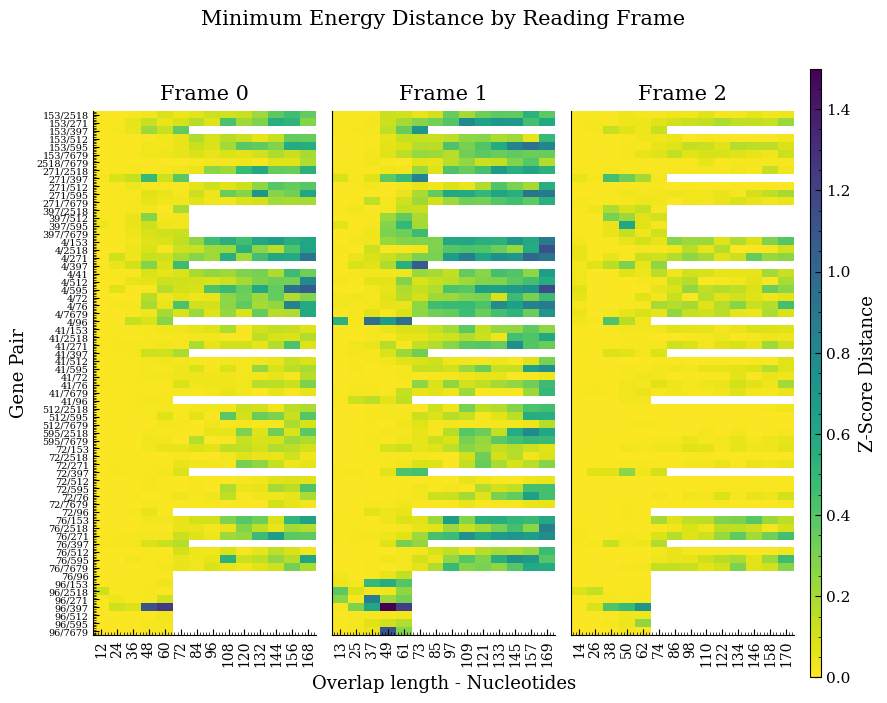

Saved: heatmap_mindist_by_frame.png


In [15]:
# --- HEATMAP: MIN DISTANCE BY FRAME ---
if 'results_df' in dir():
    fig = plot_heatmap_by_frame(results_df, 'Avg_Min_Dist', 'Minimum Energy Distance by Reading Frame', vmax=1.5)
    plt.savefig('heatmap_mindist_by_frame.png')
    plt.tight_layout
    plt.show()
    print("Saved: heatmap_mindist_by_frame.png")

In [ ]:
# --- FRAME DIFFERENCE ANALYSIS ---
# For each pair and comparable overlap range, compute frame 0 advantage

if 'results_df' in dir():
    # Group by pair and compute mean metrics per frame
    pair_frame_summary = results_df.groupby(['PF1', 'PF2', 'Reading_Frame']).agg({
        'Avg_Dist': 'mean',
        'Avg_Min_Dist': 'mean'
    }).reset_index()
    
    # Pivot to compare frames
    pivot_dist = pair_frame_summary.pivot_table(
        index=['PF1', 'PF2'], 
        columns='Reading_Frame', 
        values='Avg_Dist'
    )
    
    # Calculate how much better/worse frame 0 is compared to shifted frames
    pivot_dist['Frame0_vs_Frame1'] = pivot_dist[0] - pivot_dist[1]  # Negative = Frame 0 better
    pivot_dist['Frame0_vs_Frame2'] = pivot_dist[0] - pivot_dist[2]
    
    print("=" * 70)
    print("FRAME 0 ADVANTAGE ANALYSIS")
    print("Negative = Frame 0 has LOWER distance (better)")
    print("Positive = Frame 0 has HIGHER distance (worse)")
    print("=" * 70)
    print(f"\nFrame 0 vs Frame +1:")
    print(f"  Mean difference: {pivot_dist['Frame0_vs_Frame1'].mean():.2f}")
    print(f"  Pairs where Frame 0 is better: {(pivot_dist['Frame0_vs_Frame1'] < 0).sum()} / {len(pivot_dist)}")
    
    print(f"\nFrame 0 vs Frame +2:")
    print(f"  Mean difference: {pivot_dist['Frame0_vs_Frame2'].mean():.2f}")
    print(f"  Pairs where Frame 0 is better: {(pivot_dist['Frame0_vs_Frame2'] < 0).sum()} / {len(pivot_dist)}")

FRAME 0 ADVANTAGE ANALYSIS
Negative = Frame 0 has LOWER distance (better)
Positive = Frame 0 has HIGHER distance (worse)

Frame 0 vs Frame +1:
  Mean difference: -0.16
  Pairs where Frame 0 is better: 58 / 66

Frame 0 vs Frame +2:
  Mean difference: 0.14
  Pairs where Frame 0 is better: 9 / 66


: 

: 

: 

In [ ]:
# --- SUMMARY CONCLUSION ---

if 'results_df' in dir():
    print("=" * 70)
    print("READING FRAME ANALYSIS SUMMARY")
    print("=" * 70)
    
    # Find best frame for each metric
    frame_means = results_df.groupby('Reading_Frame')[['Avg_Dist', 'Avg_Min_Dist', 'Avg_Iter_Conv']].mean()
    
    best_dist = frame_means['Avg_Dist'].idxmin()
    best_min_dist = frame_means['Avg_Min_Dist'].idxmin()
    best_conv = frame_means['Avg_Iter_Conv'].idxmin()
    
    print(f"\nBest performing frame by metric (lower is better):")
    print(f"  Final Energy Distance:   Frame {best_dist} (mean: {frame_means.loc[best_dist, 'Avg_Dist']:.2f})")
    print(f"  Minimum Energy Distance: Frame {best_min_dist} (mean: {frame_means.loc[best_min_dist, 'Avg_Min_Dist']:.2f})")
    print(f"  Convergence Speed:       Frame {best_conv} (mean: {frame_means.loc[best_conv, 'Avg_Iter_Conv']:.0f} iterations)")
    
    print("\nMean values by frame:")
    print(frame_means.round(2))

READING FRAME ANALYSIS SUMMARY

Best performing frame by metric (lower is better):
  Final Energy Distance:   Frame 2 (mean: 0.70)
  Minimum Energy Distance: Frame 2 (mean: 0.06)
  Convergence Speed:       Frame 2 (mean: 19957 iterations)

Mean values by frame:
               Avg_Dist  Avg_Min_Dist  Avg_Iter_Conv
Reading_Frame                                       
0                  0.87          0.11       29601.66
1                  1.01          0.20       41999.97
2                  0.70          0.06       19957.13


: 

: 

: 